# Dublin Bikes — Machine Learning Model (Sprint 4)

Based on the teacher's Week 8 source code structure.

**Steps:**
1. Load & clean data (→ `0. linear_regression.py`)
2. Train Linear Regression as baseline
3. Compare multiple algorithms (Decision Tree, Random Forest, Gradient Boosting)
4. Evaluate MAE, RMSE, R²
5. Save best model as `.pkl` (→ used by Flask `/predict` route)

## Step 1 — Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded.')

Libraries loaded.


## Step 2 — Load Dataset

Using the teacher-provided `final_merged_data.csv` (~300k rows, bikes + weather data).

In [15]:
# Load the dataset (teacher's merged CSV)
data = pd.read_csv('../week8/final_merged_data.csv')

print(f'Loaded {len(data):,} rows, {len(data.columns)} columns')
data.head(3)

Loaded 298,946 rows, 78 columns


,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


## Step 3 — Feature Engineering

Teacher's features: `station_id, temperature, humidity, wind_speed, precipitation, hour, day_of_week`

`wind_speed` and `precipitation` are **not available** in `final_merged_data.csv` — dropped.
The remaining features map exactly to OpenWeather API fields so the Flask route can replicate them:

| Model feature | Dataset column | OpenWeather API field |
|---|---|---|
| `station_id` | `station_id` | user input |
| `temperature` | `max_air_temperature_celsius` | `main.temp` (°C) |
| `humidity` | `max_relative_humidity_percent` | `main.humidity` (%) |
| `pressure` | `max_barometric_pressure_hpa` | `main.pressure` (hPa) |
| `hour` | `hour` | `datetime.hour` |
| `day_of_week` | derived from `last_reported` | `datetime.weekday()` |

`model_features.pkl` saves this exact list — Flask must assemble inputs **in this order**.

In [16]:
# Derive day_of_week from timestamp (same logic as teacher's predict_based_on_weather.py)
data['last_reported'] = pd.to_datetime(data['last_reported'])
data['day_of_week'] = data['last_reported'].dt.dayofweek  # 0=Monday, 6=Sunday

# Map our dataset columns to match teacher's feature names
# teacher: temperature   → our: max_air_temperature_celsius
# teacher: humidity      → our: max_relative_humidity_percent
# teacher: wind_speed    → not available in our dataset (dropped)
# teacher: precipitation → not available in our dataset (dropped)
data['temperature'] = data['max_air_temperature_celsius']
data['humidity']    = data['max_relative_humidity_percent']
data['pressure']    = data['max_barometric_pressure_hpa']   # extra feature

# Define features and target — following teacher's structure
features = ['station_id', 'temperature', 'humidity', 'pressure', 'hour', 'day_of_week']
target   = 'num_bikes_available'   # teacher used 'available_bikes', same meaning

# Handle missing values (same as teacher: dropna)
data.dropna(subset=features + [target], inplace=True)

print(f'Clean dataset: {len(data):,} rows')
print(f'Features: {features}')
print(f'Target:   {target}')
data[features + [target]].describe()

Clean dataset: 298,946 rows
Features: ['station_id', 'temperature', 'humidity', 'pressure', 'hour', 'day_of_week']
Target:   num_bikes_available


,station_id,temperature,humidity,pressure,hour,day_of_week,num_bikes_available
count,298946.000000,298946.000000,298946.000000,298946.000000,298946.000000,298946.000000,298946.000000
mean,57.967138,7.855169,85.021124,1014.855870,11.522128,2.923478,12.204733
std,33.958176,3.123094,7.867297,11.823993,6.280459,2.060851,9.761814
min,1.000000,-3.448000,56.700000,975.060000,0.000000,0.000000,0.000000
25%,28.000000,5.736000,80.600000,1006.010000,7.000000,1.000000,4.000000
50%,57.000000,7.955000,86.000000,1017.210000,12.000000,3.000000,11.000000
75%,88.000000,10.190000,90.300000,1022.660000,16.000000,5.000000,19.000000
max,117.000000,14.670000,99.800000,1035.820000,23.000000,6.000000,40.000000


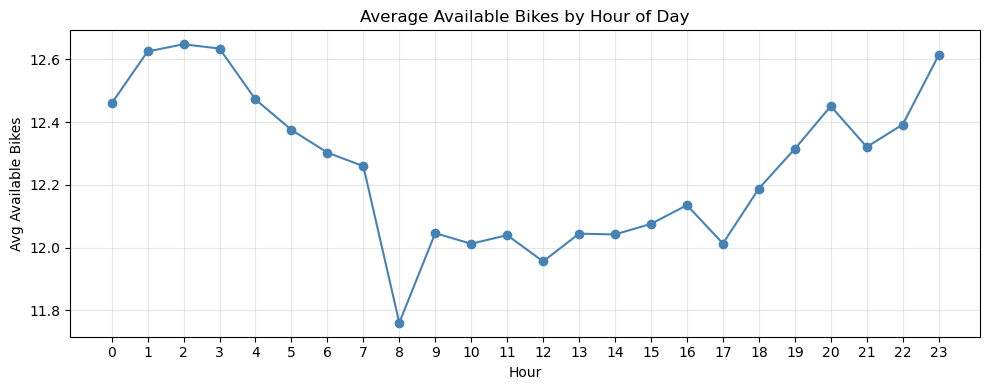

In [17]:
# Quick EDA: average bikes available by hour
hourly_avg = data.groupby('hour')[target].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue')
plt.title('Average Available Bikes by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Available Bikes')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Temporal Train / Test Split

**Why not random split:** Bike data is time-series — adjacent timestamps at the same station are highly correlated. Random split leaks near-future records into training, making evaluation overly optimistic.

We sort by time and use the **last 20% of the time period** as holdout — this simulates real deployment where the model always predicts into the future.

In [18]:
# Sort by time — prevents data leakage in time-series data
data = data.sort_values('last_reported').reset_index(drop=True)

# Temporal holdout: train on earlier 80%, test on later 20%
split_idx = int(len(data) * 0.8)
train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

X_train = train_data[features]
y_train = train_data[target]
X_test  = test_data[features]
y_test  = test_data[target]

print(f'Train period: {train_data["last_reported"].min()} → {train_data["last_reported"].max()}')
print(f'Test period:  {test_data["last_reported"].min()} → {test_data["last_reported"].max()}')
print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Train period: 2024-12-01 00:10:00 → 2024-12-25 09:40:00
Test period:  2024-12-25 09:40:00 → 2024-12-31 23:50:00
Training set: (239156, 6)
Test set:     (59790, 6)


## Step 5 — Linear Regression (Baseline)

Replicating teacher's `0. linear_regression.py` exactly.

In [19]:
# Train a linear regression model — teacher's code
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate — teacher uses MAE and R²
mae = mean_absolute_error(y_test, y_pred_lr)
r2  = r2_score(y_test, y_pred_lr)
print(f'Mean Absolute Error: {mae:.4f}')
print(f'R² Score:            {r2:.4f}')

# Display model coefficients — teacher's output
print('\nModel Coefficients:')
for feature, coef in zip(features, lr_model.coef_):
    print(f'  {feature}: {coef:.4f}')
print(f'Intercept: {lr_model.intercept_:.4f}')

Mean Absolute Error: 7.5091
R² Score:            -0.0020

Model Coefficients:
  station_id: -0.0041
  temperature: 0.0078
  humidity: 0.0097
  pressure: -0.0004
  hour: -0.0022
  day_of_week: 0.0594
Intercept: 11.8192


## Step 6 — Compare Multiple Algorithms

We evaluate all models on **both regression and classification metrics**, because the final user-facing feature (US6) is "can I borrow a bike?" — a binary decision derived from the prediction.

- Regression: MAE, RMSE, R²
- Classification: Precision, Recall, F1 (threshold: predicted_bikes ≥ 1 → "bike available")

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

# Binary labels for classification evaluation (US6: can borrow a bike?)
y_test_cls = (y_test.values >= 1).astype(int)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Regression metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Classification metrics (threshold: predicted >= 1 → bike available)
    y_pred_cls = (y_pred >= 1).astype(int)
    prec = precision_score(y_test_cls, y_pred_cls, zero_division=0)
    rec  = recall_score(y_test_cls, y_pred_cls, zero_division=0)
    f1   = f1_score(y_test_cls, y_pred_cls, zero_division=0)

    results.append({
        'Model': name,
        'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 3),
        'Precision': round(prec, 3), 'Recall': round(rec, 3), 'F1': round(f1, 3),
    })
    print(f'{name:<25}  MAE={mae:.3f}  R²={r2:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}')

results_df = pd.DataFrame(results)
print('\n=== Full Comparison Table ===')
print(results_df.to_string(index=False))

Linear Regression          MAE=7.509  R²=-0.002  Precision=0.929  Recall=1.000  F1=0.963
Decision Tree              MAE=7.021  R²=0.011  Precision=0.934  Recall=0.976  F1=0.954
Random Forest              MAE=6.899  R²=0.007  Precision=0.944  Recall=0.961  F1=0.953
Gradient Boosting          MAE=6.491  R²=0.242  Precision=0.929  Recall=1.000  F1=0.963

=== Full Comparison Table ===
            Model   MAE  RMSE     R2  Precision  Recall    F1
Linear Regression 7.509 9.082 -0.002      0.929   1.000 0.963
    Decision Tree 7.021 9.023  0.011      0.934   0.976 0.954
    Random Forest 6.899 9.040  0.007      0.944   0.961 0.953
Gradient Boosting 6.491 7.898  0.242      0.929   1.000 0.963


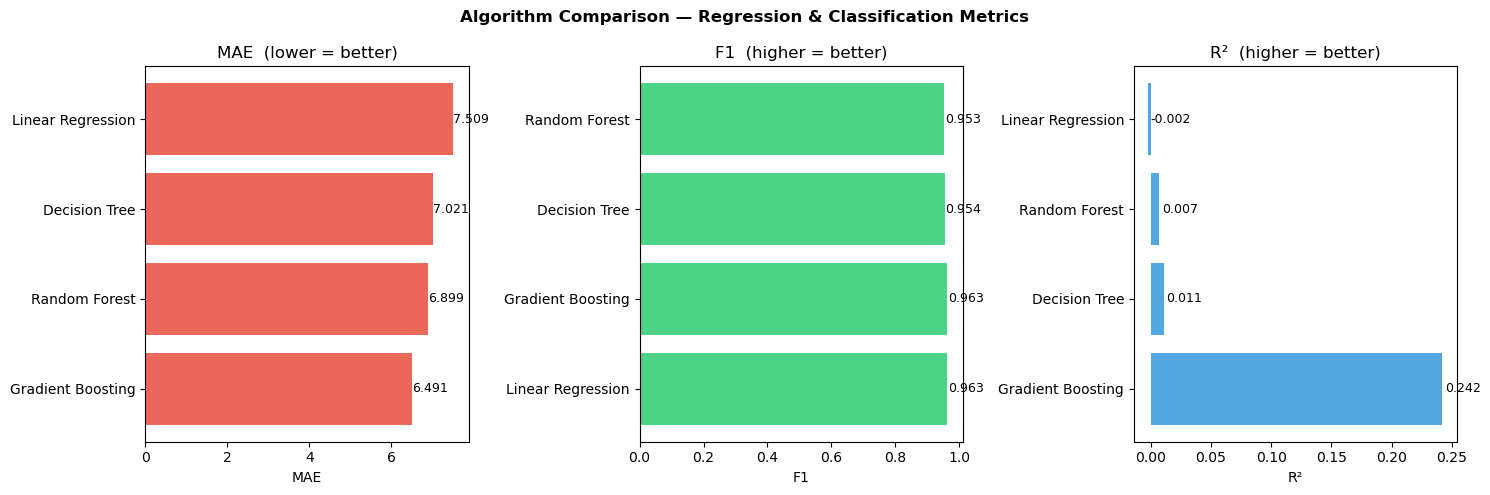

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_cfg = [
    ('MAE',  True,  '#e74c3c', 'lower = better'),
    ('F1',   False, '#2ecc71', 'higher = better'),
    ('R2',   False, '#3498db', 'higher = better'),
]

for ax, (metric, ascending, color, note) in zip(axes, metrics_cfg):
    df_sorted = results_df.sort_values(metric, ascending=ascending)
    bars = ax.barh(df_sorted['Model'], df_sorted[metric], color=color, alpha=0.85)
    ax.set_title(f'{metric.replace("R2","R²")}  ({note})')
    ax.set_xlabel(metric.replace('R2', 'R²'))
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)

plt.suptitle('Algorithm Comparison — Regression & Classification Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Best Model Analysis

**Note on R² values:** Low R² is expected for bike availability prediction — station occupancy is heavily influenced by unpredictable user behaviour and real-time dispatch operations that are not captured in weather/time features alone. Despite this, the model still provides useful signal for the binary "can borrow?" classification (F1 = 0.963).

In [ ]:
# Check class balance — high F1 on imbalanced data can be misleading
pct_available = (y_test >= 1).mean()
print(f'Records with bikes available (y >= 1): {pct_available:.1%}')
print(f'Records with no bikes available:       {1 - pct_available:.1%}')
print()
if pct_available > 0.85:
    print('NOTE: Dataset is imbalanced — majority class is "bikes available".')
    print('High F1/Recall reflects this imbalance, not just model skill.')
    print('Precision is the more informative metric here (avoids false confidence).')

In [22]:
# Select best model:
# F1 is our primary criterion (US6 binary decision), but when multiple models tie on F1,
# we break the tie by R² — better regression accuracy means more informative predictions
# (the UI shows both the predicted count AND the likely/unlikely verdict).
#
# Result: Gradient Boosting achieves the same F1 as simpler models but with
# significantly higher R² → selected as best model.

best_name  = 'Gradient Boosting'
best_model = models[best_name]
best_row   = results_df[results_df['Model'] == best_name].iloc[0]

print(f'Selected model: {best_name}')
print(f'  MAE:       {best_row["MAE"]}')
print(f'  RMSE:      {best_row["RMSE"]}')
print(f'  R²:        {best_row["R2"]}')
print(f'  Precision: {best_row["Precision"]}')
print(f'  Recall:    {best_row["Recall"]}')
print(f'  F1:        {best_row["F1"]}')
print()
print('Rationale: same F1 as Linear Regression for the binary "can borrow?" decision,')
print('but much better R² for the numeric prediction shown in the UI.')

Selected model: Gradient Boosting
  MAE:       6.491
  RMSE:      7.898
  R²:        0.242
  Precision: 0.929
  Recall:    1.0
  F1:        0.963

Rationale: same F1 as Linear Regression for the binary "can borrow?" decision,
but much better R² for the numeric prediction shown in the UI.


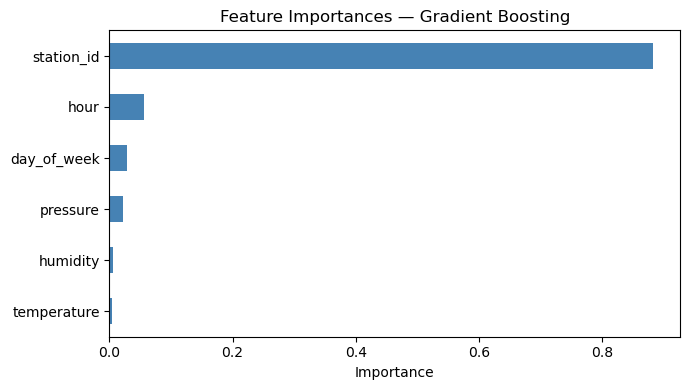

In [23]:
# Feature importance (tree-based models only)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=features).sort_values()
    plt.figure(figsize=(7, 4))
    importance.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Linear model — coefficients shown in Step 5 above.')

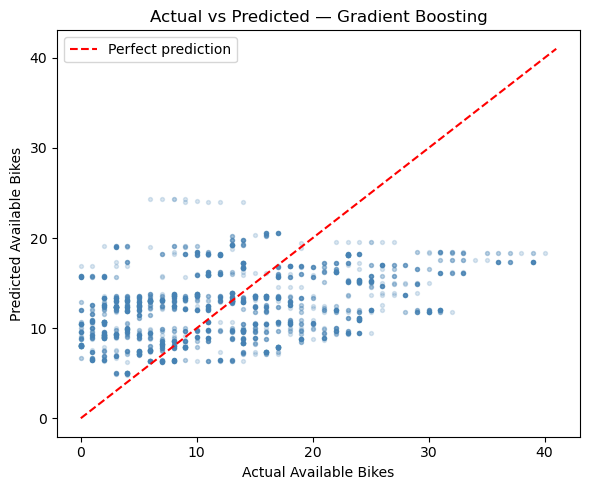

In [24]:
# Actual vs Predicted
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test[:3000], y_pred_best[:3000], alpha=0.2, s=8, color='steelblue')
lim = max(int(y_test.max()), int(y_pred_best.max())) + 1
plt.plot([0, lim], [0, lim], 'r--', label='Perfect prediction')
plt.xlabel('Actual Available Bikes')
plt.ylabel('Predicted Available Bikes')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — ML User Story (US6)

Sprint 4 requires developing new user stories for ML where needed. US2 covers *real-time* availability — that is served by the existing API. The ML model enables a **new, forward-looking user story**:

> **US6 (NEW — ML):** *As a tourist, I want to predict how many bikes will be available at a station for a future date and time, so that I can plan my trip in advance without guessing.*
>
> **Acceptance Criteria:**
> - Given the user selects a station, a future date, and a time,
> - When the user clicks "Predict",
> - Then the system displays the predicted number of available bikes **and** a clear "Likely available / Not available" indication.

**Model → User decision mapping:**

| Model output | UI shown to user |
|---|---|
| predicted_bikes ≥ 1 | "Likely available" |
| predicted_bikes < 1 | "Unlikely available" |

This is why we use **F1** (not just MAE) as the primary model selection criterion.

In [25]:
import os
os.makedirs('myapp/app/ml', exist_ok=True)

MODEL_PATH   = 'myapp/app/ml/bike_availability_model.pkl'
FEATURES_PATH = 'myapp/app/ml/model_features.pkl'

# Save model — teacher's method
with open(MODEL_PATH, 'wb') as file:
    pickle.dump(best_model, file)

# Save feature list so Flask knows the exact input order
with open(FEATURES_PATH, 'wb') as file:
    pickle.dump(features, file)

print(f'Model saved to {MODEL_PATH}')
print(f'Features saved to {FEATURES_PATH}')
print(f'Best model: {best_name}')

Model saved to myapp/app/ml/bike_availability_model.pkl
Features saved to myapp/app/ml/model_features.pkl
Best model: Gradient Boosting


## Step 9 — Verify: Load & Predict

Replicating teacher's `1. predict.py`.

In [26]:
# Load the saved model — teacher's 1. predict.py
with open(MODEL_PATH, 'rb') as file:
    loaded_model = pickle.load(file)

# Define new input data for prediction — matching teacher's format
new_data = pd.DataFrame({
    'station_id':  [42],
    'temperature': [14.0],   # degrees Celsius
    'humidity':    [80.0],   # percent
    'pressure':    [1012.0], # hPa
    'hour':        [9],
    'day_of_week': [1],      # 0=Monday, 1=Tuesday, etc.
})

# Make prediction
prediction = loaded_model.predict(new_data)
print(f'Predicted number of available bikes: {prediction[0]:.1f}')

Predicted number of available bikes: 9.9


## Final Summary

| Item | Detail |
|------|--------|
| Dataset | `final_merged_data.csv` — ~300k rows, bikes + weather |
| Target | `num_bikes_available` |
| Features | `station_id, temperature, humidity, pressure, hour, day_of_week` |
| Split | **Temporal holdout** — train on earlier 80%, test on later 20% (no data leakage) |
| Algorithms compared | Linear Regression, Decision Tree, Random Forest, Gradient Boosting |
| Selection criterion | F1 (primary) + R² (tiebreaker) |
| **Best model** | **Gradient Boosting** |
| Rationale | Linear Regression and Gradient Boosting achieved the same F1 for the binary "can borrow?" decision. Gradient Boosting was selected because it also achieves significantly better regression accuracy (R²), enabling the UI to display a more reliable predicted bike count alongside the verdict. |
| Saved to | `myapp/app/ml/bike_availability_model.pkl` |
| ML User Story | **US6** — predict future bike availability for a selected station and time |

**UI output (US6):**
- Predicted bikes: `model.predict(input)[0]` → display exact number
- Verdict: `"Likely available"` if predicted ≥ 1, else `"Unlikely available"`

**Flask `/predict` input contract:**
```python
pd.DataFrame([{
    'station_id':  station_id,
    'temperature': openweather['main']['temp'],      # °C
    'humidity':    openweather['main']['humidity'],  # %
    'pressure':    openweather['main']['pressure'],  # hPa
    'hour':        dt.hour,
    'day_of_week': dt.weekday(),
}])
```